## Building Chatbots With Multiple Tools Using LangGraph

Aim:
- Create a chatbot with tool capabilities from ArXiv, Wikipedia search and other functions

In [2]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [5]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [6]:
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wikipedia = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
print(wikipedia.name)

wikipedia


In [7]:
wikipedia.invoke("What is Machine Learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [8]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [9]:
## Tavily Tool
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

/var/folders/kt/hhlws00n53502tnyykkz678r0000gn/T/ipykernel_1141/794941660.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [10]:
tavily.invoke("What is the latest news in AI?")

[{'title': 'The latest AI news we announced in January - Google Blog',
  'url': 'https://blog.google/innovation-and-ai/products/google-ai-updates-january-2026/',
  'content': 'We added a new Search experience to even more seamlessly explore information. Search continues to evolve to make it effortless to find whatever is on your mind, no matter how complex the question. Gemini 3 is the new default model for AI Overviews globally, so you get a best-in-class AI response right on the search results page, for questions where it’s helpful. Plus, now you can easily ask a follow-up question right from an AI Overview, and jump into a conversational back and forth with AI Mode. [...] In January, we moved AI toward a new era of Personal Intelligence: making products like Search, Chrome and the Gemini app more proactive than ever. Whether it’s Chrome’s “auto browse” handling your complex chores or Gmail surfacing what matters most, these new personalization features are focused on anticipating yo

In [11]:
## Combine all the tools in the list
tools = [arxiv, wikipedia, tavily]

In [12]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x108c8acf0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1285afe00>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [14]:
llm_with_tools = llm.bind_tools(tools)

In [15]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

llm_with_tools.invoke([
    HumanMessage(content="What is the latest news in AI?")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'nspb4jw2q', 'function': {'arguments': '{"query":"latest news in AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 555, 'total_tokens': 576, 'completion_time': 0.052697319, 'completion_tokens_details': None, 'prompt_time': 0.03373872, 'prompt_tokens_details': None, 'queue_time': 0.04817842, 'total_time': 0.086436039}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_68f543a7cc', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c4b50-2a4a-7871-80e5-3320b762233b-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest news in AI'}, 'id': 'nspb4jw2q', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 555, 'output_tokens': 21, 'total_tokens': 576})

In [16]:
llm_with_tools.invoke([
    HumanMessage(content="What is the latest news in AI?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest news in AI'},
  'id': 'dktteagje',
  'type': 'tool_call'}]

In [17]:
## Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [18]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

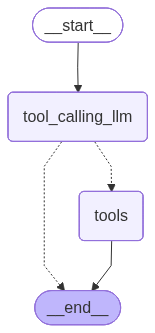

In [20]:
## Node Function

def tool_calling_llm(state: State) -> State:
    return {"messages": llm_with_tools.invoke(state["messages"])}

## Graph Construction
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
messages = graph.invoke({
    "messages": HumanMessage(content="What is the latest news in AI?")})

for message in messages["messages"]:
    print(message.content)

What is the latest news in AI?

[{"title": "Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025", "url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "content": "programmable work to AI, deliver superior results, boosting overall performance by 68.7%. The study argues that in high-stakes domains such as law, medicine, or engineering, hybrid, multimodal workflows under human supervision should remain the standard. [...] Summary: A former Google software engineer has been convicted on multiple counts of trade secret theft after a federal investigation revealed he illicitly transferred over 500 confidential files related to Google’s proprietary artificial intelligence infrastructure. The stolen data included critical details on \"TPU\" (Tensor Processing Unit) chips and software used to power large-scale machine learning models. Prosecutors established that the engineer was secretly working for two China-based technology companies while still employed at Googl

In [23]:
messages = graph.invoke({
    "messages": HumanMessage(content="What is the latest news in AI?")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the latest news in AI?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (yykkh00wq)
 Call ID: yykkh00wq
  Args:
    query: latest news in AI
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "## Latest\n\nAI and Us\n\nFebruary 5, 2026\n\n# AI Expo 2026 Day 2: Moving experimental pilots to AI production\n\nAI in Action\n\nFebruary 5, 2026\n\n# OpenAI’s enterprise push: The hidden story behind AI’s sales race\n\nPhoto from AI & Big Data Expo as while the prospect of AI acting as a digital co-worker dominated the day one agenda at the co-located AI & Big Data Expo and Intelligent Automation Conference, the technical ses

In [24]:
messages = graph.invoke({
    "messages": HumanMessage(content="1706.03762")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (xq8rmed9a)
 Call ID: xq8rmed9a
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [22]:
messages

{'messages': [HumanMessage(content='What is the latest news in AI?', additional_kwargs={}, response_metadata={}, id='25fd1f9c-6ef6-483f-a6b8-058a33e04677'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '1rgxb1ah0', 'function': {'arguments': '{"query":"latest news in AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 555, 'total_tokens': 576, 'completion_time': 0.055287501, 'completion_tokens_details': None, 'prompt_time': 0.031592604, 'prompt_tokens_details': None, 'queue_time': 0.049133726, 'total_time': 0.086880105}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c4b61-a5df-7bc0-82fe-63cfc7816d03-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'latest news in AI'}, 'id': '1rgxb1ah0', 'type': 'too